<a href="https://colab.research.google.com/github/debraluna/DebraLuna_DTSC3020_Summer2026/blob/main/ADTA4230_FINAL_PROJECT_CAR_CRASH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ADTA 4230 Final Project Car Crash

# Student: Debra Luna
# Student: Renesme Torres

# Predicting Car Injury Severity Using the Car-Crash Dataset

# The objective for this project is to develop and compare two classification
# models that whether a motor vehicle results in a severe or fatal injury
# Logistic regression and Forest Classification models will be used to analyze
# the relationship between traffic violation factors, car crash severity, roadway, and environmental.

In [ ]:
# ADTA 4230 Final Project Car Crash
# Predicting Crash Injury Severity Using the Car Crash Dataset

# import libraries

import pandas as pd
myData = pd.read_excel('Appendix_A_data.xlsx', sheet_name = 'Car Crash')

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Model Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Display all columns
pd.set_option('display.max_columns', None)

# Make graphs look cleaner
plt.rcParams["figure.figsize"] = (8,5)

print("Libraries Imported Successfully!")


Libraries Imported Successfully!


In [ ]:
# upload dataset
import os
print(os.listdir('/content'))

['.config', 'jag2602x_appA_830_836_G.pdf', 'Appendix_A_data.xlsx', 'sample_data']


In [ ]:
# read the excel file
import pandas as pd

excel_file = "Appendix_A_data.xlsx"

myData = pd.ExcelFile(excel_file)

print(myData.sheet_names)

['Car Crash', 'College_Admissions', 'COVID_Testing', 'House_Price', 'Longitudinal Survey', 'NBA', 'TechSales_Reps']


In [ ]:
# load the car crash dataset
myData = pd.read_excel('Appendix_A_data.xlsx', sheet_name = 'Car Crash')

# Display the first five row
myData.head()

,ID,County,City,Weekday,Severity,ViolCat,ClearWeather,Month,CrashType,Highway,Daylight
0,1,SAN DIEGO,SAN DIEGO,7,1,8,0,1,A,0,1
1,2,HUMBOLDT,UNINCORPORATED,4,1,8,1,1,A,1,0
2,3,VENTURA,OXNARD,2,1,12,1,2,A,0,1
3,4,STANISLAUS,UNINCORPORATED,4,1,1,1,1,A,0,0
4,5,MENDOCINO,UNINCORPORATED,5,1,1,1,1,A,1,0


In [ ]:
# Overview of Dataset
print(myData.shape)
print(myData.info())

print("\n")

print("Colunmn Names:")
print(myData.columns.tolist())

print("\n")

print("Data Types:")
print(myData.dtypes)

(112660, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112660 entries, 0 to 112659
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   ID            112660 non-null  int64 
 1   County        112660 non-null  object
 2   City          112660 non-null  object
 3   Weekday       112660 non-null  int64 
 4   Severity      112660 non-null  int64 
 5   ViolCat       112660 non-null  int64 
 6   ClearWeather  112660 non-null  int64 
 7   Month         112660 non-null  int64 
 8   CrashType     112660 non-null  object
 9   Highway       112660 non-null  int64 
 10  Daylight      112660 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 9.5+ MB
None


Colunmn Names:
['ID', 'County', 'City', 'Weekday', 'Severity', 'ViolCat', 'ClearWeather', 'Month', 'CrashType', 'Highway', 'Daylight']


Data Types:
ID               int64
County          object
City            object
Weekday          int64
Severity         in

In [ ]:
# Dataset Overview
# the car crash dataset contains 112,600 motor vehicle crash records and 11
# variables desribing the crash characteristics, environmental conditions, injury severity, and roadway features
# The dataset also features both categorical and numerical variables.
# Numerical variables include identifiers and binary indicators such as the severity, highway, daylight, clear weather, while categorical varibles include county, city, and crash type
# the target variable for this project is Severity:
# - 1 = fatal or severe injury
# - 0 = other crash outcomes

# as for the remaining variables, they will serve as a predictor variable for building the classification models

In [ ]:
# scan for missing values
print(myData.isnull().sum())

ID              0
County          0
City            0
Weekday         0
Severity        0
ViolCat         0
ClearWeather    0
Month           0
CrashType       0
Highway         0
Daylight        0
dtype: int64


In [ ]:
# look for duplicate rows
print("Duplicate Rows:", myData.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# crash severity distribution
print(myData["Severity"].value_counts())

print()

print(myData["Severity"].value_counts(normalize=True) * 100)

Severity
0    104742
1      7918
Name: count, dtype: int64

Severity
0    92.971773
1     7.028227
Name: proportion, dtype: float64


In [ ]:
# violation categories
print(myData["ViolCat"].value_counts().sort_index())

ViolCat
1      9953
3     39691
4      3134
6       764
7      5241
8     17188
9     19807
10     3645
11     3488
12     9744
24        5
Name: count, dtype: int64


In [ ]:
# data cleaning

# the dataset was examined for data quality issues before the model development

# We performed the following preprocessing steps:
# Verified that there were no repeating of or duplicated records
# Made sure there were no missing values
# Replaced all of the number 12 values in the ViolCat column with the value 2, as per dr. tong's recommendation
# we removed the five observations that contained the undocumented value 24 in the ViolCat variable
# Removed the ID variable from modeling becuse it is only a unique identifier and does not contain any necessary predictive information

In [ ]:
# replace the incorrect violation code
myData["ViolCat"] = myData["ViolCat"].replace(12,2)

In [ ]:
# Remove the undocumented violation category
myData = myData[myData["ViolCat"] != 24]

In [ ]:
# verify
print(myData["ViolCat"].value_counts().sort_index())

ViolCat
1      9953
2      9744
3     39691
4      3134
6       764
7      5241
8     17188
9     19807
10     3645
11     3488
Name: count, dtype: int64


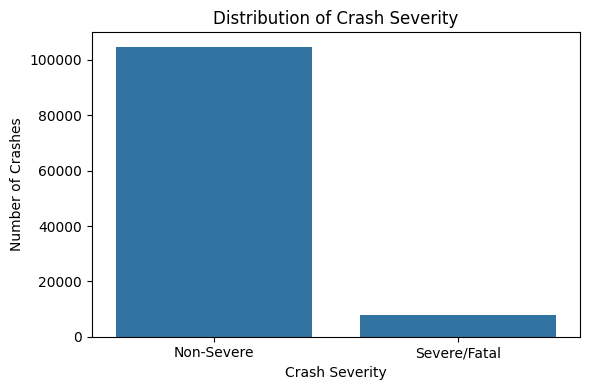

In [ ]:
# EDA
# Graph 1 - Severity Distribution

plt.figure(figsize=(6,4))

ax = sns.countplot(data=myData, x="Severity")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Non-Severe", "Severe/Fatal"])

plt.title("Distribution of Crash Severity")
plt.xlabel("Crash Severity")
plt.ylabel("Number of Crashes")

plt.tight_layout()
plt.show()

In [ ]:
# the majority of the crashes in the dataset resulted in non-severe outcomes. Approx. 92.97% (93%) of observations belong to the non-severe class, while only 7.03% (7%) resulted in severe/fatal injuries. The class imbalance is important because relying solely on accuracy may overestimate the model performance. Moving forward, we will use additional evaluation metrics such as precision, F1-score, ROC-AUC, and recall to compare the classification models.

In [ ]:
# EDA Graph 2: the Crash Type
# create crash type labels and replace crash type codes with descriptive names

myData["CrashType"].unique()

myData["CrashType"].value_counts().sort_index()

,count
CrashType,
A,6055
B,9847
C,40387
D,29855
E,13966
F,4855
G,7690


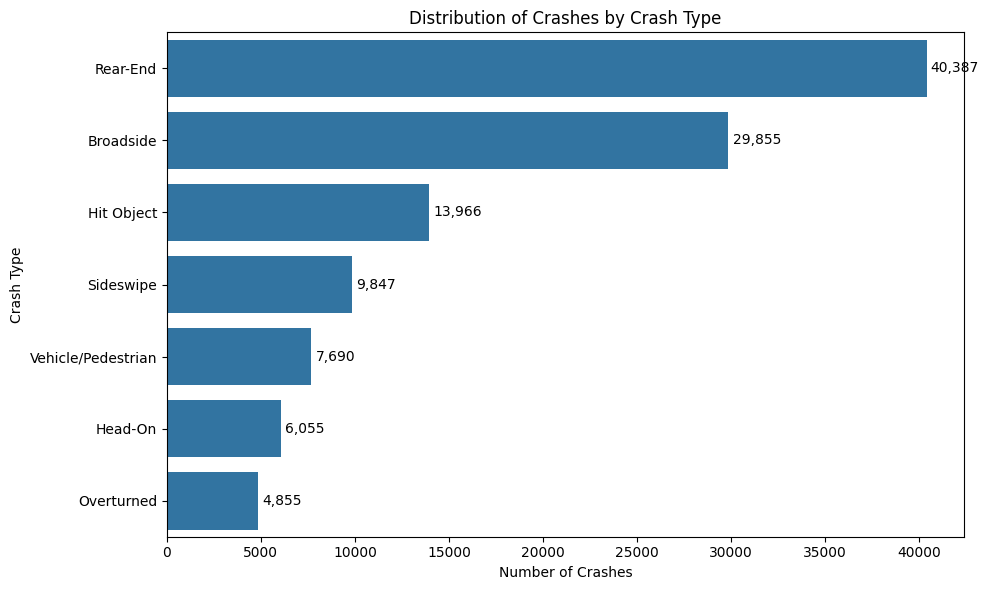

In [ ]:
# create clean crash type labels

crash_type_labels = {
    "A": "Head-On",
    "B": "Sideswipe",
    "C": "Rear-End",
    "D": "Broadside",
    "E": "Hit Object",
    "F": "Overturned",
    "G": "Vehicle/Pedestrian"
}

myData["CrashType_Label"] = myData["CrashType"].map(crash_type_labels)

plt.figure(figsize=(10,6))

ax = sns.countplot(data=myData, y="CrashType_Label", order=myData["CrashType_Label"].value_counts().index
)

# add formatted counts to each bar add in commas remove %
for container in ax.containers:
    labels = [f"{int(v):,}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

plt.title("Distribution of Crashes by Crash Type")
plt.xlabel("Number of Crashes")
plt.ylabel("Crash Type")

plt.tight_layout()
plt.show()

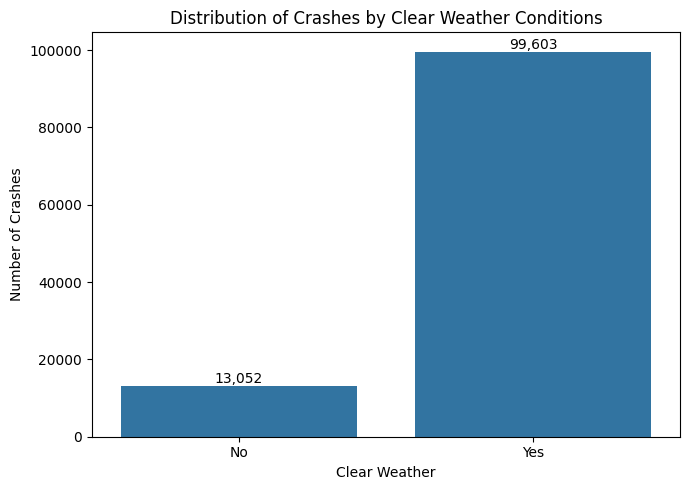

In [ ]:
# Graph 3: The Weather Conditions

plt.figure(figsize=(7,5))

ax = sns.countplot(data=myData, x="ClearWeather")

# add labels to each bar
for container in ax.containers:
  labels = [f"{int(v):,}" for v in container.datavalues]
  ax.bar_label(container, labels=labels)

plt.xticks([0, 1], ["No", "Yes"])

plt.title("Distribution of Crashes by Clear Weather Conditions")
plt.xlabel("Clear Weather")
plt.ylabel("Number of Crashes")

plt.tight_layout()
plt.show()

# the majority of crashes occurred during certain weather conditions. These results show that bad weather is not the primary cause to these crashes. Factors such as bad driving, road conditions, and traffic violations should also be taken into consideration when trying to predict the severity of a crash.

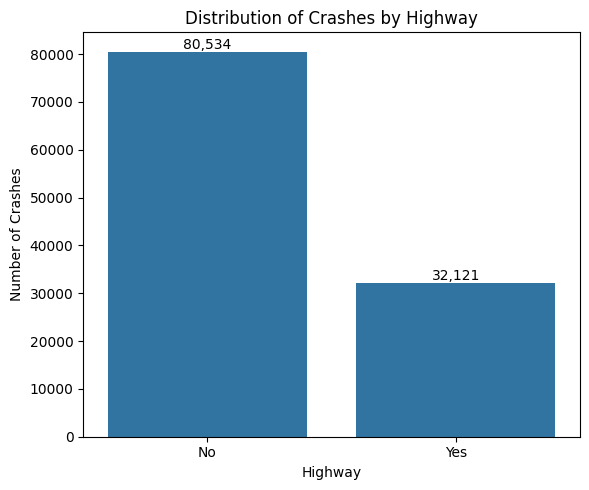

In [ ]:
# Graph 4: Highway

plt.figure(figsize=(6,5))

ax = sns.countplot(data=myData, x="Highway")

# add labels to each bar
for container in ax.containers:
  labels = [f"{int(v):,}" for v in container.datavalues]
  ax.bar_label(container, labels=labels)

plt.xticks([0, 1], ["No", "Yes"])

plt.title("Distribution of Crashes by Highway")
plt.xlabel("Highway")
plt.ylabel("Number of Crashes")

plt.tight_layout()
plt.show()

# the majority of the crashes in this dataset occurred on non-highway roads at approx. 71.5% of all crashes. However, highway crashes often occur at higher speeds so the highway variable might still be relevant when trying to predict the severe or fatal injuries which is why we will be including the classification models

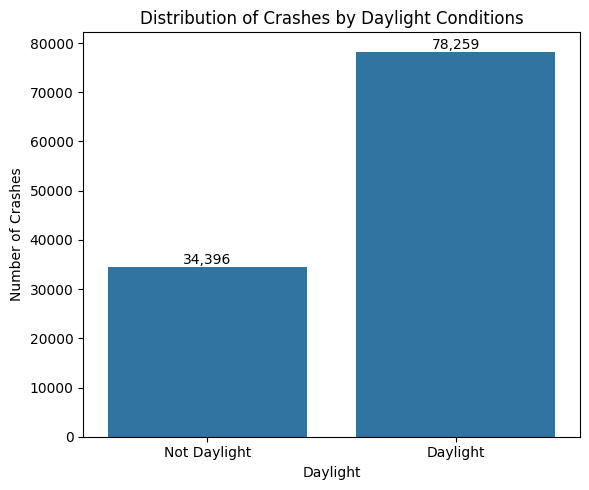

In [ ]:
# Graph 5: Daylight

plt.figure(figsize=(6,5))

ax = sns.countplot(data=myData, x="Daylight")

# add count labels
for container in ax.containers:
  labels = [f"{int(v):,}" for v in container.datavalues]
  ax.bar_label(container, labels=labels)

# set x-axis labels
plt.xticks([0, 1], ["Not Daylight", "Daylight"])

plt.title("Distribution of Crashes by Daylight Conditions")
plt.xlabel("Daylight")
plt.ylabel("Number of Crashes")

plt.tight_layout()
plt.show()

# the distribution of crashes by daylight conditions helps us determine if visibility of daytime or night time influences a crash occurence and it's severity. This will be considered a potential predictor when using the classificaiton models

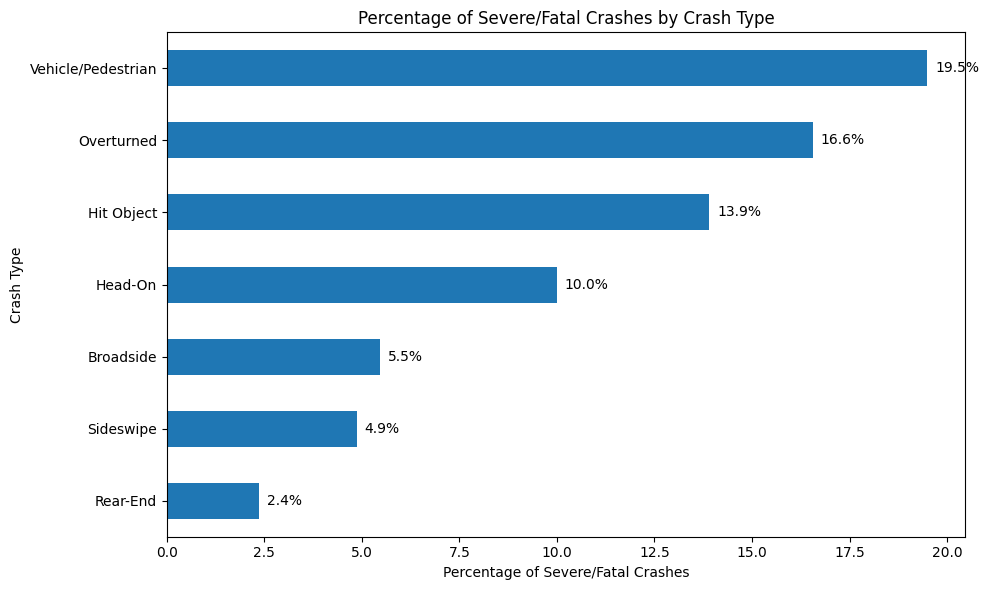

In [ ]:
# EDA Graph: Percentage of Severe/Fatal Crasshes

# calculate the percentage of the severe/fatal crashes for each crash type
severity_by_type = (
    pd.crosstab(myData["CrashType_Label"], myData["Severity"], normalize="index") * 100
)
# keep only the percentage of severe/fatal crashes (Severity = 1)
severity_percent = severity_by_type[1].sort_values(ascending=True)

plt.figure(figsize=(10,6))

ax = severity_percent.plot(kind="barh")

# add the percentage labels
for i, value in enumerate(severity_percent):
  ax.text(value + 0.2, i, f"{value:.1f}%", va="center")

plt.title("Percentage of Severe/Fatal Crashes by Crash Type")
plt.xlabel("Percentage of Severe/Fatal Crashes")
plt.ylabel("Crash Type")

plt.tight_layout()
plt.show()

# this graph shows the percentage of crashes within each crash type that resulted either in sever or fatal injuries. This analysis gives insight to which crash types have a higher risk for injury and supports the generating of predictive classification models

In [ ]:
# Modeling

#The objective for this project is to predict whether a motor vehicle crash results in a severe or fatal injury. The following two classifications will be used and compared:
# - Logistic Regression
# - Random Forest Classifier

# After testing using multiple evaluation metrics, we will choose the best-performing model

In [ ]:
# remove the ID we do not need it for this model
myData_model = myData.drop(columns=["ID"])

# create modeling dataset
myData_model = myData.copy()

# Remove columns we don't want in the model
myData_model = myData_model.drop(columns=["ID", "CrashType_Label"], errors="ignore")

myData_model.head()

# Convert categorical variables into dummy variables
myData_encoded = pd.get_dummies(
    myData_model,
    columns=["CrashType", "County", "City"],
    drop_first=True
)

print(myData_encoded.shape)
myData_encoded.head()

# predictor variables
X = myData_encoded.drop(columns="Severity")

# target variable
y = myData_encoded["Severity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

(112655, 507)
X shape: (112655, 506)
y shape: (112655,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=321,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (78858, 506)
Testing set shape: (33797, 506)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data standardization complete.")

Data standardization complete.


In [ ]:
# Logistic Regression Model
# the first classification model developed for this project is logistic regression because the target variable (Severity) is highly imbalanced and the model uses balanced class weights to minimize bias toward the majority class
# We will evaluate the performance of the model by using F1-score, ROC-AUC, accuracy, precision, recall, and the confusion matrix

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

# build logistic regression model
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=321
)

# train the model
log_model.fit(X_train_scaled, y_train)

# make predictions on the test set
log_pred = log_model.predict(X_test_scaled)

# predict probabilities
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Accuracy
print("Accuracy:")
print(round(accuracy_score(y_test, log_pred), 4))

# classification report
print("\nClassification Report:")
print(classification_report(y_test, log_pred))

# ROC-AUC
print("\nROC-AUC:")
print(round(roc_auc_score(y_test, log_prob), 4))

Accuracy:
0.7096

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82     31422
           1       0.15      0.67      0.25      2375

    accuracy                           0.71     33797
   macro avg       0.56      0.69      0.53     33797
weighted avg       0.91      0.71      0.78     33797


ROC-AUC:
0.7461


In [ ]:
# recreate logistic regression predictions correctly

# predict classes: 0 or 1
log_pred = log_model.predict(X_test_scaled)

# Predicted probabilities: values between 0 and 1
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predictions:")
print(log_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(log_prob[:10])

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.2879914  0.19423584 0.42285457 0.12638652 0.29549466 0.33200516
 0.32318782 0.38657591 0.28374392 0.13608765]


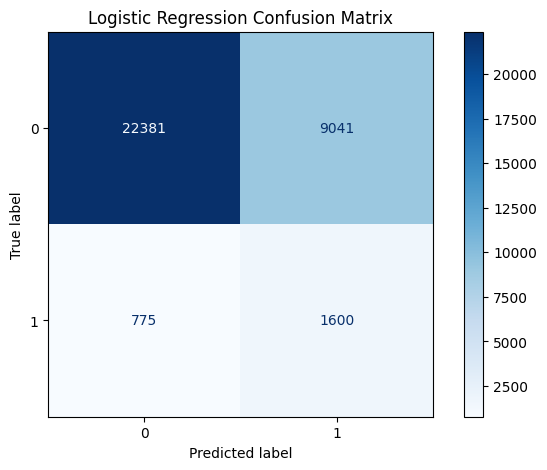

In [ ]:
# Logistic regression confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, log_pred)

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

cm_display.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=321,
    n_jobs=-1
)

# Train using the original unscaled data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_pred = rf_model.predict(X_test)

# predict probabilities
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:")
print(round(accuracy_score(y_test, rf_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nROC-AUC:")
print(round(roc_auc_score(y_test, rf_prob), 4))

Accuracy:
0.9117

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     31422
           1       0.19      0.08      0.11      2375

    accuracy                           0.91     33797
   macro avg       0.56      0.53      0.53     33797
weighted avg       0.88      0.91      0.89     33797


ROC-AUC:
0.7021


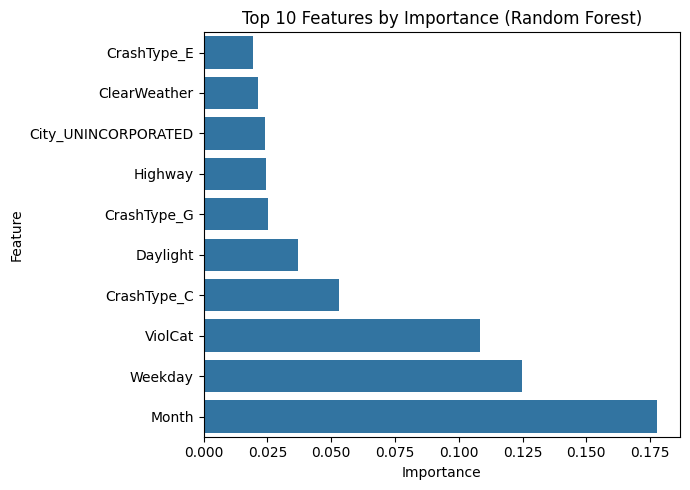

,Feature,Importance
3,Month,0.177814
0,Weekday,0.124906
1,ViolCat,0.108388
7,CrashType_C,0.052956
5,Daylight,0.037032
11,CrashType_G,0.025426
4,Highway,0.024330
469,City_UNINCORPORATED,0.024188
2,ClearWeather,0.021251
9,CrashType_E,0.019395


In [ ]:
# Feature the importance from Random Forest graph

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

top10 = feature_importance.sort_values(
    by="Importance",
    ascending=False
    ).head(10)

plt.figure(figsize=(7,5))

sns.barplot(
    data=top10,
     x="Importance",
     y="Feature"
)

plt.title("Top 10 Features by Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

top10

# Analysis
# Using a Random Forest Classifier, we found that Month, ViolCat, and Weekday were the top three predictors of crash severity. Even when the model evaluated climate, crash type, daylight conditions, highway status, and city, the data still shows that severe or fatal outcomes are a combination of temporal patterns, environmental conditions, and driver behavior

In [ ]:
print("y_test" in globals())
print("log_pred" in globals())
print("log_prob" in globals())
print("rf_pred" in globals())
print("rf_prob" in globals())

True
True
True
True
True


In [ ]:
# summarizing the models in one table
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score

)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        round(accuracy_score(y_test, log_pred), 4),
        round(accuracy_score(y_test, rf_pred), 4)
    ],
    "Precision": [
        round(precision_score(y_test, log_pred, zero_division=0), 4),
        round(precision_score(y_test, rf_pred, zero_division=0), 4)
    ],
    "Recall": [
        round(recall_score(y_test, log_pred), 4),
        round(recall_score(y_test, rf_pred), 4)
    ],
    "F1-Score": [
        round(f1_score(y_test, log_pred), 4),
        round(f1_score(y_test, rf_pred), 4)
    ],
    "ROC-AUC": [
        round(roc_auc_score(y_test, log_prob), 4),
        round(roc_auc_score(y_test, rf_prob), 4)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7096,0.1504,0.6737,0.2459,0.7461
1,Random Forest,0.9117,0.1929,0.0804,0.1135,0.7021
